In [ ]:
1. Load Dataset

In [3]:
import pandas as pd

df = pd.read_csv('food.csv')

if 'Country' in df.columns:
    df = df.set_index('Country')
else:
    df = df.set_index(df.columns[0])

print(df.head())

                RedMeat  WhiteMeat  Eggs  Milk  Fish  Cereals  Starch  Nuts  \
Unnamed: 0                                                                    
Albania            10.1        1.4   0.5   8.9   0.2     42.3     0.6   5.5   
Austria             8.9       14.0   4.3  19.9   2.1     28.0     3.6   1.3   
Belgium            13.5        9.3   4.1  17.5   4.5     26.6     5.7   2.1   
Bulgaria            7.8        6.0   1.6   8.3   1.2     56.7     1.1   3.7   
Czechoslovakia      9.7       11.4   2.8  12.5   2.0     34.3     5.0   1.1   

                Fr.Veg  
Unnamed: 0              
Albania            1.7  
Austria            4.3  
Belgium            4.0  
Bulgaria           4.2  
Czechoslovakia     4.0  


2. Preprocess data

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

3. Apply KMeans clustering

In [5]:
from sklearn.cluster import KMeans
from sklearn import metrics

#Preparing the list for the Silhouette scores
silhouette_scores = []
k_range = range(2, 6) # k from 2 to 5

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_scaled)
    
    # 4. Compute the Silhouette coefficient
    score = metrics.silhouette_score(df_scaled, labels)
    silhouette_scores.append((k, score))
    print(f"Silhouette Score für k={k}: {score}")

# 5. Select the best k based on the highest score
best_k = max(silhouette_scores, key=lambda x: x[1])[0]
print(f"\nDas beste k ist: {best_k}")

# Execute KMeans with the best k final
kmeans_final = KMeans(n_clusters=best_k, random_state=42)
final_labels = kmeans_final.fit_predict(df_scaled)

Silhouette Score für k=2: 0.3271084145417136
Silhouette Score für k=3: 0.3351693984160507
Silhouette Score für k=4: 0.2798600378321701
Silhouette Score für k=5: 0.21400058012556447

Das beste k ist: 3


4. Visualize final KMeans clustering using PCA


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 8.1/8.1 MB 9.0 MB/s eta 0:00:00
     -------------------------------------- 225.2/225.2 kB 3.4 MB/s eta 0:00:00
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
     ---------------------------------------- 2.3/2.3 MB 11.5 MB/s eta 0:00:00
     -------------------------------------- 73.5/73.5 kB 810.8 kB/s eta 0:00:00
     ---------------------------------------- 7.1/7.1 MB 14.1 MB/s eta 0:00:00
     -------------------------------------- 122.8/122.8 kB 3.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


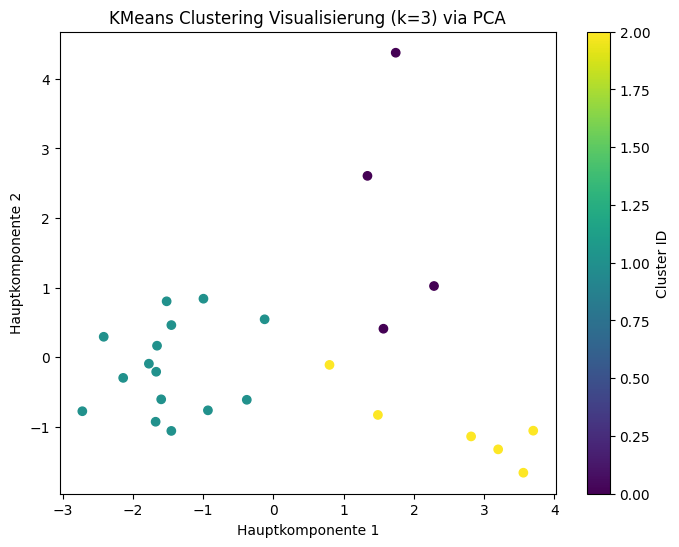

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce data to 2 components
pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_scaled)

# Plot cluster
plt.figure(figsize=(8, 6))
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=final_labels, cmap='viridis')
plt.title(f'KMeans Clustering Visualisierung (k={best_k}) via PCA')
plt.xlabel('Hauptkomponente 1')
plt.ylabel('Hauptkomponente 2')
plt.colorbar(label='Cluster ID')
plt.show()

5. Perform hierarchical clustering

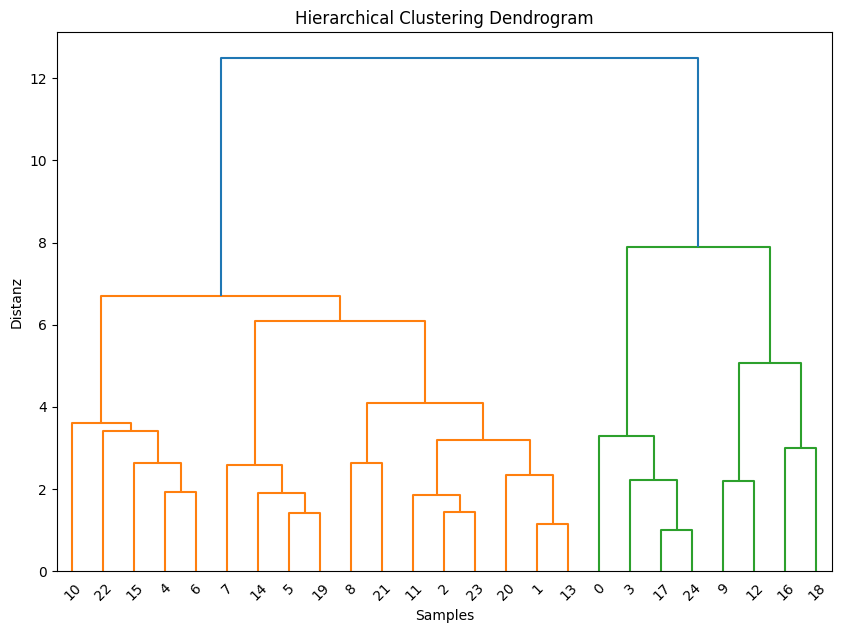

In [8]:
from scipy.cluster.hierarchy import linkage, dendrogram

# Hierarchical clustering with linkage
Z = linkage(df_scaled, method='ward')

# Dendrogramm plot
plt.figure(figsize=(10, 7))
dendrogram(Z)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Distanz')
plt.show()

6. Create a heatmap


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     -------------------------------------- 294.9/294.9 kB 2.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


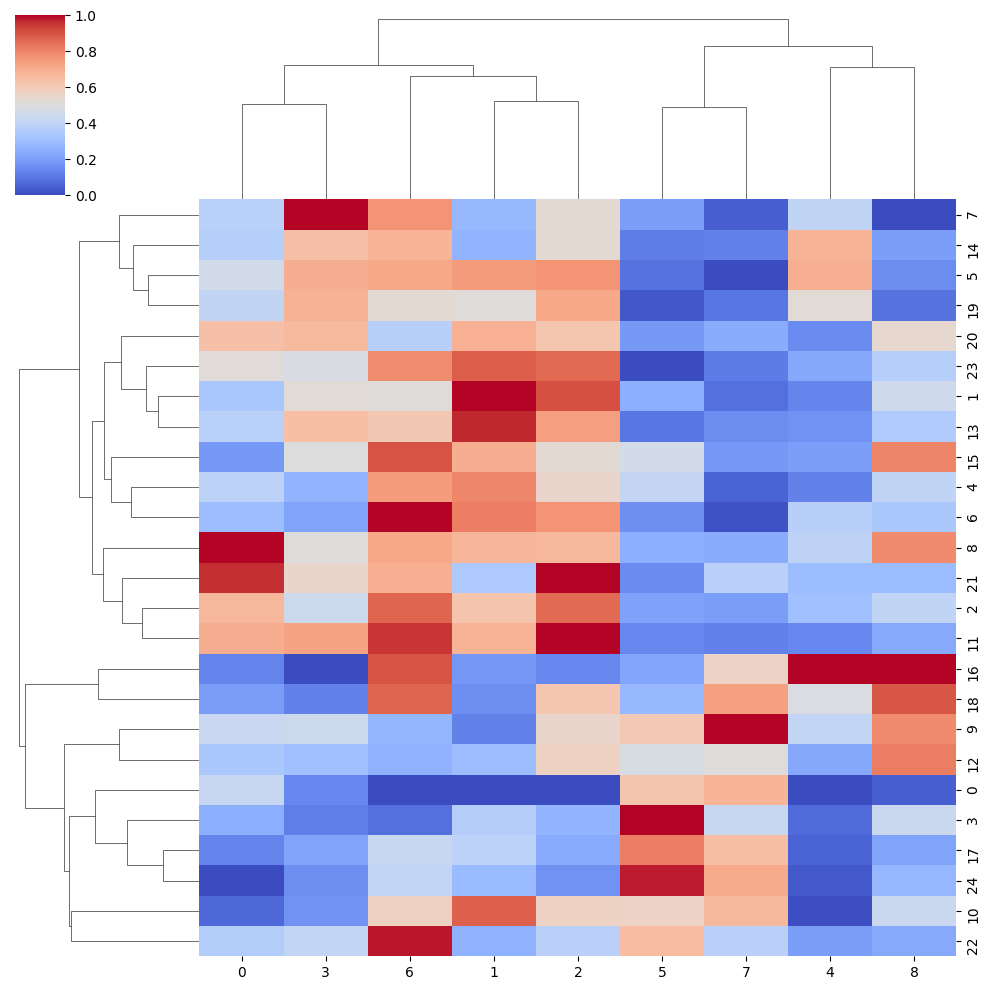

In [ ]:
import seaborn as sns

# Heatmap with cluster map (clustering of samples and variables)
sns.clustermap(df_scaled, cmap='coolwarm', standard_scale=1)
plt.show()

7. Perform density-based clustering

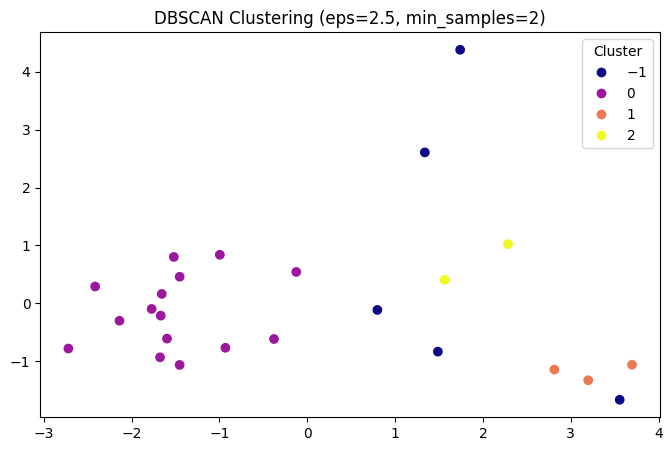

Cluster-Labels: [-1  0  0  1  0  0  0  0  0  2 -1  0  2  0  0  0 -1  1 -1  0  0  0 -1  0
  1]


In [13]:
from sklearn.cluster import DBSCAN

# Calculate the model (adjust EPS if everything remains -1)
dbscan = DBSCAN(eps=2.5, min_samples=2)
labels_db = dbscan.fit_predict(df_scaled)

# Visualization
plt.figure(figsize=(8, 5))
scatter = plt.scatter(pca_data[:, 0], pca_data[:, 1], c=labels_db, cmap='plasma')

# Legend and title
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.title("DBSCAN Clustering (eps=2.5, min_samples=2)")
plt.show()

print("Cluster-Labels:", labels_db)